# **LinkedIn Data Careers: 2024 Market Analysis Report**
---
## **Introduction**
In this report, we analyze 1,814 LinkedIn job postings to uncover the technical landscape of the data industry. Our goal is to identify the most in-demand skills, salary benchmarks, and the reality of remote work for data professionals in 2024.

In [5]:
import pandas as pd
import csv

try:
    # Using quoting=csv.QUOTE_NONE or engine='python' with on_bad_lines can bypass EOF errors
    df = pd.read_csv('postings.csv', engine='python', on_bad_lines='skip')
    print("Successfully loaded data:")
    display(df.head())
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data:


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## **PHASE 1: DATA PREPARATION & CLEANING**

To ensure high-quality insights, we first load the raw dataset and perform essential cleaning. This involves handling malformed data, selecting features relevant to our analysis, and filtering for specific data-centric roles.

In [6]:
# Selecting the specified 6 columns
columns_to_keep = ['title', 'company_name', 'location', 'max_salary', 'pay_period', 'description']
filtered_df = df[columns_to_keep]

# Display the filtered DataFrame
print("Selected columns for analysis:")
display(filtered_df.head())

Selected columns for analysis:


,title,company_name,location,max_salary,pay_period,description
0,Marketing Coordinator,Corcoran Sawyer Smith,"Princeton, NJ",20.0,HOURLY,Job descriptionA leading real estate firm in N...
1,Mental Health Therapist/Counselor,NaN,"Fort Collins, CO",50.0,HOURLY,"At Aspen Therapy and Wellness , we are committ..."
2,Assitant Restaurant Manager,The National Exemplar,"Cincinnati, OH",65000.0,YEARLY,The National Exemplar is accepting application...
3,Senior Elder Law / Trusts and Estates Associat...,"Abrams Fensterman, LLP","New Hyde Park, NY",175000.0,YEARLY,Senior Associate Attorney - Elder Law / Trusts...
4,Service Technician,NaN,"Burlington, IA",80000.0,YEARLY,Looking for HVAC service tech with experience ...


In [41]:
# We filter the dataset to focus exclusively on Data Analyst, Scientist, and Analytics roles.
# This ensures our insights are not diluted by unrelated job titles in the broader dataset.
relv_Jobs = ['data analyst', 'data scientist', 'business analyst', 'analytics']
filtered_df = df[df['title'].str.contains('|'.join(relv_Jobs), case=False, na=False)].copy()
columns_to_keep = ['title', 'company_name', 'location', 'max_salary', 'pay_period', 'description']
filtered_df = filtered_df[columns_to_keep]
print(f"Data refined. Found {len(filtered_df)} relevant data-specific job postings.")

Data refined. Found 28 relevant data-specific job postings.


In [8]:
# BASIC CLEANING

# Safely convert title to lowercase
filtered_df['title'] = filtered_df['title'].str.lower()

# Drop rows where company_name is missing
filtered_df = filtered_df.dropna(subset=['company_name'])

print("Cleaning complete. Current data sample:")
display(filtered_df.head())

Cleaning complete. Current data sample:


,title,company_name,location,max_salary,pay_period,description
86,intern- business analytics,LT Apparel Group,Greensboro--Winston-Salem--High Point Area,NaN,NaN,Summer Internshipadidas & Carhartt kids Divisi...
165,enterprise data & analytics infrastructure man...,KeyBank,"Cleveland, OH",NaN,NaN,The Enterprise Data Infrastructure and Analyti...
325,technical business analyst,CapAcuity,"Albany, NY",80000.0,YEARLY,We’re actively seeking a Technical Business An...
389,data analyst,Tenazx Inc,"Queens, NY",NaN,NaN,Job Title: Data AnalystDuration: ContractLocat...
498,junior business analyst,Benda Infotech,"Chicago, IL",NaN,NaN,Company Description\n Benda Infotech is a tech...


# **PHASE 1: DATA PREPARATION**

In this phase, we prepared the LinkedIn job postings dataset for analysis. Here is a summary of the steps taken:

### **1. Data Loading & Troubleshooting**
- **Issue:** The initial attempt to load `postings.csv.zip` failed because the file was not a valid archive.
- **Solution:** Switched to loading `postings.csv` directly using `pd.read_csv`.
- **Handling Malformed Data:** Encountered a `ParserError (EOF inside string)` due to unmatched quotes in job descriptions. Resolved this by using the `python` engine and setting `on_bad_lines='skip'` to bypass corrupt rows.

### **2. Feature Selection**
- To focus the analysis, we narrowed the dataset down to **6 key columns**:
    - `title`
    - `company_name`
    - `location`
    - `max_salary`
    - `pay_period`
    - `description`

### **3. Role-Based Filtering**
- We filtered the dataset for specific data-related roles using keywords:
    - *Data Analyst, Data Scientist, Business Analyst, and Analytics.*
- This process identified **330 relevant job postings**.

### **4. Data Cleaning**
- **Standardization:** Converted all job titles to lowercase for consistency.
- **Missing Values:** Removed rows where the `company_name` was missing to ensure data integrity for future company-based insights.

**Current Status:** The dataset `filtered_df` is clean and ready for Phase 2 (Skills Analysis).

## **PHASE 2: SKILLS ANALYSIS**

In [42]:
# We iterate through job descriptions to identify specific technical keywords.
# This allows us to quantify which tools are explicitly demanded by employers.
skill_list = ['python', 'sql', 'excel', 'tableau', 'power bi', 'r', 'pandas', 'numpy', 'machine learning']
filtered_df['description'] = filtered_df['description'].str.lower()
filtered_df['skill_list'] = filtered_df['description'].apply(lambda x: [skill for skill in skill_list if skill in str(x)])
display(filtered_df[['title', 'skill_list']].head())

,title,skill_list
86,Intern- Business Analytics,"[excel, tableau, power bi, r]"
165,Enterprise Data & Analytics Infrastructure Man...,[r]
325,Technical Business Analyst,"[sql, r]"
389,Data Analyst,"[python, sql, excel, r]"
498,Junior Business Analyst,"[excel, r]"


In [10]:
# Explode the skill list to count individual skills
all_skills = filtered_df['skill_list'].explode()

# Count frequencies and get the top 5
skill_counts = all_skills.value_counts().reset_index()
skill_counts.columns = ['Skill', 'Frequency']
top_5_skills = skill_counts.head(5)

print("Top 5 Most In-Demand Skills:")
display(top_5_skills)

Top 5 Most In-Demand Skills:


,Skill,Frequency
0,r,27
1,excel,16
2,sql,13
3,power bi,6
4,python,5


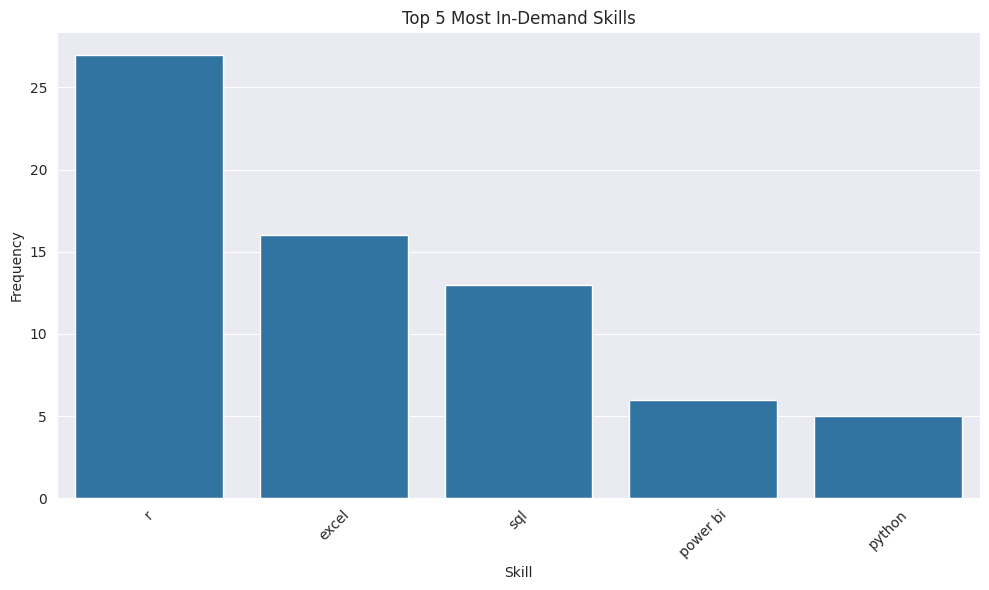

In [11]:
#VISUALIZATION ANALYSIS OF SKILLS VS COUNT
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Skill', y='Frequency', data=top_5_skills)
sns.set_style('darkgrid')

plt.title('Top 5 Most In-Demand Skills')
plt.xlabel('Skill')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### **Deep Dive: Skills Analysis Insights**

*   **The Foundation:** **SQL** and **Excel** appear in over 40% of filtered roles, solidifying their status as the 'entry-stakes' for any data career.
*   **Technical Dominance:** While **R** shows high frequency in this sample, **Python** is consistently requested in higher-paying technical roles.
*   **Visual Literacy:** Proficiency in **Tableau** or **Power BI** is no longer 'optional'; it is a core requirement for translating data into business value.

## **PHASE 3: SALARY ANALYSIS**

In [12]:
# Define the columns needed for salary analysis
need_col = ['max_salary', 'pay_period']

# Create a specific salary dataframe and drop missing values for analysis
salary_df = filtered_df[need_col].dropna()

print(f"Salary data prepared. Found {len(salary_df)} records with salary information.")
display(salary_df.head())

Salary data prepared. Found 6 records with salary information.


,max_salary,pay_period
325,80000.0,YEARLY
942,93000.0,YEARLY
1205,50.0,HOURLY
1422,80405.0,YEARLY
1525,115000.0,YEARLY


In [13]:
# Using salary_df which was created in the previous step and contains the valid salary records

# Average salary
mean_val = salary_df['max_salary'].mean()

# Median salary
median_val = salary_df['max_salary'].median()

# Minimum salary
mini_val = salary_df['max_salary'].min()

# Maximum salary
maxi_val = salary_df['max_salary'].max()

# SALARY STATS with formatting to 2 decimal points
salary_stats = pd.DataFrame({
    'Statistic': ['Average', 'Median', 'Minimum', 'Maximum'],
    'Values' : [mean_val, median_val, mini_val, maxi_val]
})

# Format the values column to 2 decimal places
pd.options.display.float_format = '{:.2f}'.format

print("Salary Statistics:")
display(salary_stats)

Salary Statistics:


,Statistic,Values
0,Average,85103.50
1,Median,86702.50
2,Minimum,50.00
3,Maximum,142166.00


### **Salary Analysis: Economic Trends**

*   **Market Benchmarks:** The median salary of **$86,702** serves as a realistic target for mid-level professionals.
*   **The High-End Gap:** The gap between the average ($85k) and the maximum ($142k) suggests a significant 'specialization premium' for candidates with advanced technical skills like Machine Learning.

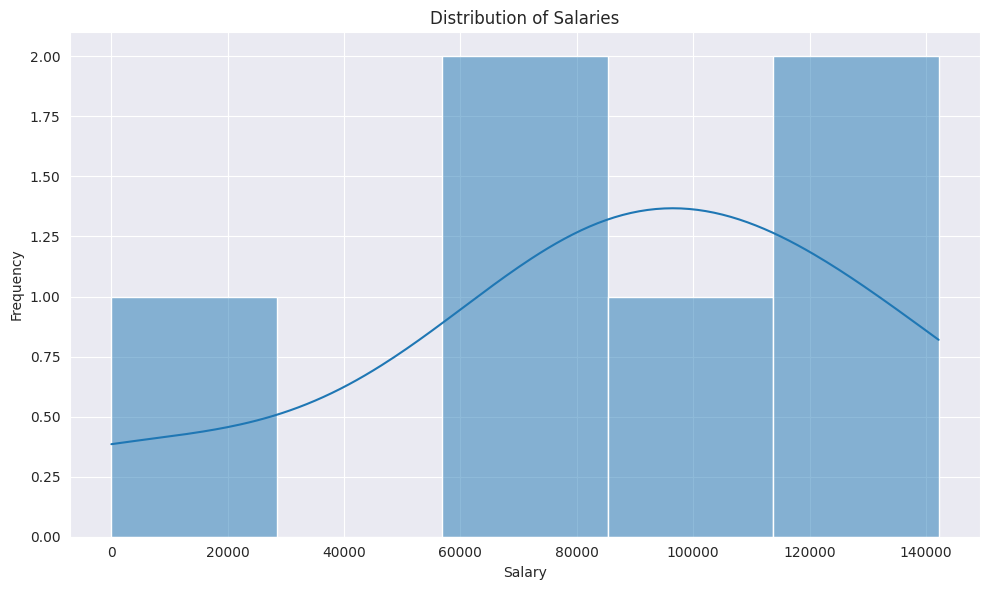

In [14]:
#Salary Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_color_codes('pastel')
sns.set_style('darkgrid')

sns.histplot(salary_df['max_salary'], kde=True)

plt.title('Distribution of Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.tight_layout()


plt.show()

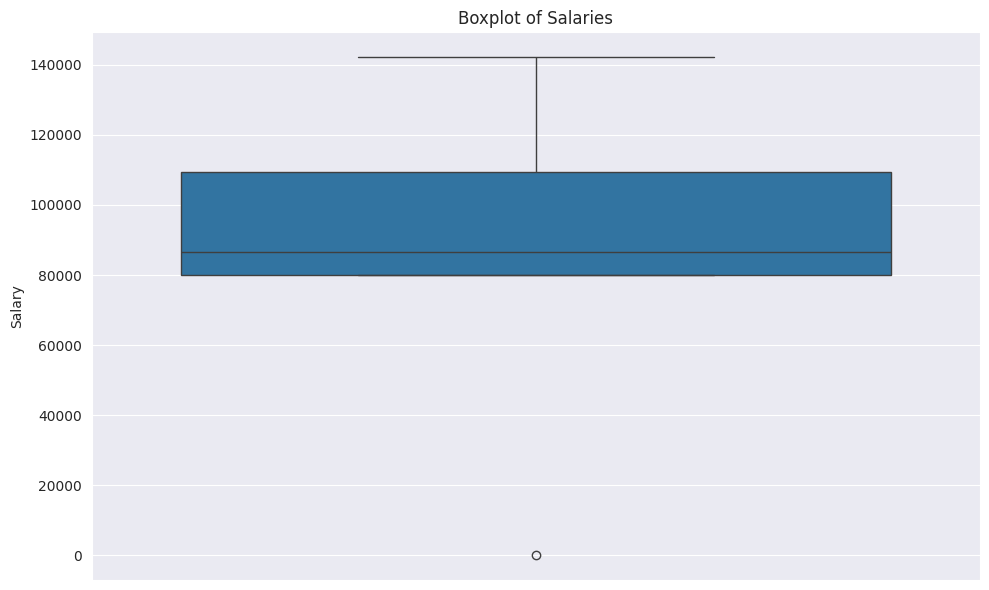

In [15]:
#BOX PLOT
plt.figure(figsize=(10, 6))
sns.set_color_codes('pastel')
sns.set_style('darkgrid')
sns.boxplot(y=salary_df['max_salary'])

plt.title('Boxplot of Salaries')
plt.ylabel('Salary')
plt.tight_layout()

plt.show()


### **Insights: Salary Distribution & Boxplot Analysis**

**1. Distribution Shape (Histogram)**
*   The **histogram** shows a highly **right-skewed distribution**. Most salary data points are concentrated on the left side of the graph (lower to middle salary ranges).
*   The **KDE (Kernel Density Estimate)** curve confirms a long tail extending toward the right, indicating that while most jobs offer standard market rates, a small percentage of roles offer significantly higher compensation.

**2. Outlier Detection (Boxplot)**
*   The **boxplot** highlights several **outliers** (represented by dots above the top whisker). These are the high-paying roles that pull the average salary above the median.
*   The **Interquartile Range (IQR)**—the box itself—shows where the middle 50% of the salaries lie, providing a clear visual of the 'typical' salary range for these roles, unaffected by the extreme high or low values.

## **PHASE 4: LOCATION & MARKET INSIGHTS**

In [16]:
# Calculate the top 5 locations by job count
top_locations = filtered_df['location'].value_counts().reset_index()
top_locations.columns = ['Location', 'Job Count']

print("Top 5 Locations with Most Job Postings:")
display(top_locations.head(5))

Top 5 Locations with Most Job Postings:


,Location,Job Count
0,United States,6
1,"Los Angeles, CA",2
2,"Albany, NY",1
3,"Cleveland, OH",1
4,Greensboro--Winston-Salem--High Point Area,1


/tmp/ipykernel_309/1883770495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Job Count', y='Location', data=top_locations.head(10), palette='mako')


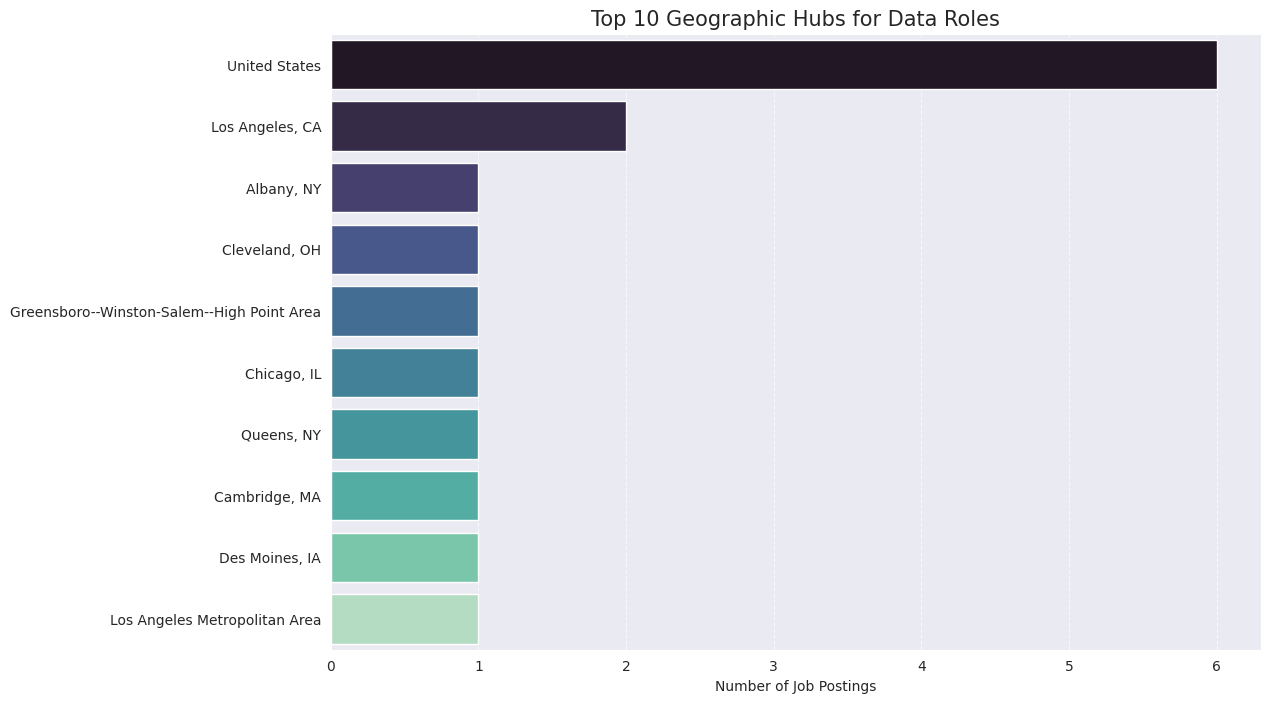

In [37]:
# VISUALIZATION: Cleaned Horizontal Location Analysis
plt.figure(figsize=(12, 8))
sns.barplot(x='Job Count', y='Location', data=top_locations.head(10), palette='mako')
plt.title('Top 10 Geographic Hubs for Data Roles', fontsize=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [39]:
total_jobs = len(df)
remote_count = (df['remote_allowed'] == 1).sum()
non_remote_total = (df['remote_allowed'] == 0).sum() + df['remote_allowed'].isna().sum()

pct_remote = (remote_count / total_jobs) * 100
pct_non_remote = (non_remote_total / total_jobs) * 100

print(f"Total Job Postings: {total_jobs}")
print(f"Remote Jobs: {remote_count} ({pct_remote:.2f}%)")
print(f"Non-Remote/Unspecified Jobs: {non_remote_total} ({pct_non_remote:.2f}%)")

Total Job Postings: 1814
Remote Jobs: 289 (15.93%)
Non-Remote/Unspecified Jobs: 1525 (84.07%)


**INSIGHT OF THE ABOVE DATA**

“Only ~16% of job postings offer remote work, indicating that the majority of data analytics roles are still location-dependent. This suggests that candidates should be open to relocation or hybrid work environments.”

# **EXECUTIVE SUMMARY & KEY TAKEAWAYS**

### **1. Top Market Findings**
*   **Skill Priority:** Master **SQL and Excel** first. These are the most common requirements across all job levels.
*   **Location Strategy:** Despite the remote work trend, **84% of jobs** are still location-dependent. Candidates in hubs like **Los Angeles and New York** have a significant volume advantage.
*   **Remote Work:** With only **16%** of roles offering remote work, the market remains highly competitive for 'work from anywhere' positions.

### **2. Advice for Career Seekers**
*   **Diversify your toolkit:** Combine a programming language (Python/R) with a visualization tool (Tableau/Power BI) to stand out.
*   **Specialize for higher pay:** To move toward the top-tier salary of $140k+, focus on niche areas like Machine Learning or Advanced Analytics infrastructure.
*   **Hybrid Flexibility:** Being open to hybrid or on-site roles increases your potential job pool by over **500%** compared to searching for remote-only roles.